In [2]:
# Description: Plot Figure 4 (Shelf edge cross-isobath geostrophic velocity and nitrate time-means and seasonal anomalies)
#               and Figure 5 (Cross-shelf edge nitrate transport and spatial nitrate distribution)
# Author:      André Palóczy

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from xarray import open_dataset
from pandas import DataFrame, read_json
from cmocean.cm import balance, delta, matter, tarn_r

from matplotlib.gridspec import GridSpec
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.crs as ccrs
proj = ccrs.PlateCarree()
from cartopy.feature import LAND

## Define file paths

In [9]:
def near2(x, y, x0, y0):
    dr2 = (x - x0)**2 + (y - y0)**2
    return int(np.nanargmin(dr2))

d = np.load("../proc/isobath_200m.npz")
xi, yi, di = d["xi"], d["yi"], d["di"]
xseg0, yseg0 = np.loadtxt("../proc/segment_latitudes_wei_etal2024.txt", unpack=True)
fseg = [near2(xi, yi, xseg0[i], yseg0[i]) for i in range(len(yseg0))]

# Clip start/end to fit segments.
xseg, yseg = xi[fseg], yi[fseg]
dibound = di[fseg]
txt_segs = ["AS", "CSS", "PSBS", "MS", "HS", "WSS", "NENSS"]

# Also clip 100 m isobath just for plotting.
d = np.load("../proc/isobath_100m.npz")
xi100, yi100 = d["xi_ext"], d["yi_ext"]
fclip100l = near2(xi100, yi100, xseg0[0], yseg0[0])
fclip100r = near2(xi100, yi100, xseg0[-1], yseg0[-1]) + 1
xi100, yi100 = xi100[fclip100l:fclip100r], yi100[fclip100l:fclip100r]

def annotate_segments(axi, dibound=dibound, txt_segs=txt_segs, ytxt=-190):
    for i in range(len(txt_segs)):
        xtxt = 0.5*(dibound[i] + dibound[i+1])
        axi.text(xtxt, ytxt, txt_segs[i], ha="center", va="center", fontsize=13, color="k", bbox=dict(boxstyle="round,pad=0.3", fc="w", ec="k", lw=1))

def annotate_segments2(axi, dibound=dibound, txt_segs=txt_segs, ytxt=-100, fontsize=14, txtcol="k", txtweight="black"):
    for i in range(len(txt_segs)):
        xtxt = 0.5*(dibound[i] + dibound[i+1])
        axi.text(xtxt, ytxt, txt_segs[i], ha="center", va="center", rotation=90, fontsize=fontsize, color=txtcol, fontweight=txtweight, zorder=99999)

f = "../proc/alongisob_seasonal_WOA23_200m.nc"

ds = open_dataset(f)
ug, N, ugN = ds["ug"], ds["N"], ds["ugN"]
rho = ds["rho"]
ug_annual = ug.sel(t="annual")
ug_annual_s = ug_annual - ug_annual.sel(z=0)
N_annual = N.sel(t="annual")

x, z = ds["x"].values, ds["z"].values

ugmax = 5 # [cm/s]
dug = 2.5 # [cm/s]
uglevs = np.concatenate([np.arange(-ugmax, dug, dug), np.arange(dug, ugmax + dug, dug)])
ugmax_diff = 0.5 # [cm/s]

nlevsc = 10
Dmi, Dma = 25.0, 27.5 # [kg/m3]
Dlevsc = np.linspace(Dmi, Dma, num=nlevsc)
Dccl = Dlevsc[::2]

# Nmin, Nmax = 2, 12 # [mmol/m3]
Nmin, Nmax = 1, 13 # [mmol/m3]

Nlevs = np.arange(Nmin, Nmax+2, 2)
N_diff = 5 # [mmol/m3]

ts = ds["t"].values
ts_ssn = ts[1:]

getfattr: Removing leading '/' from absolute path names


## Plot Figure 4.

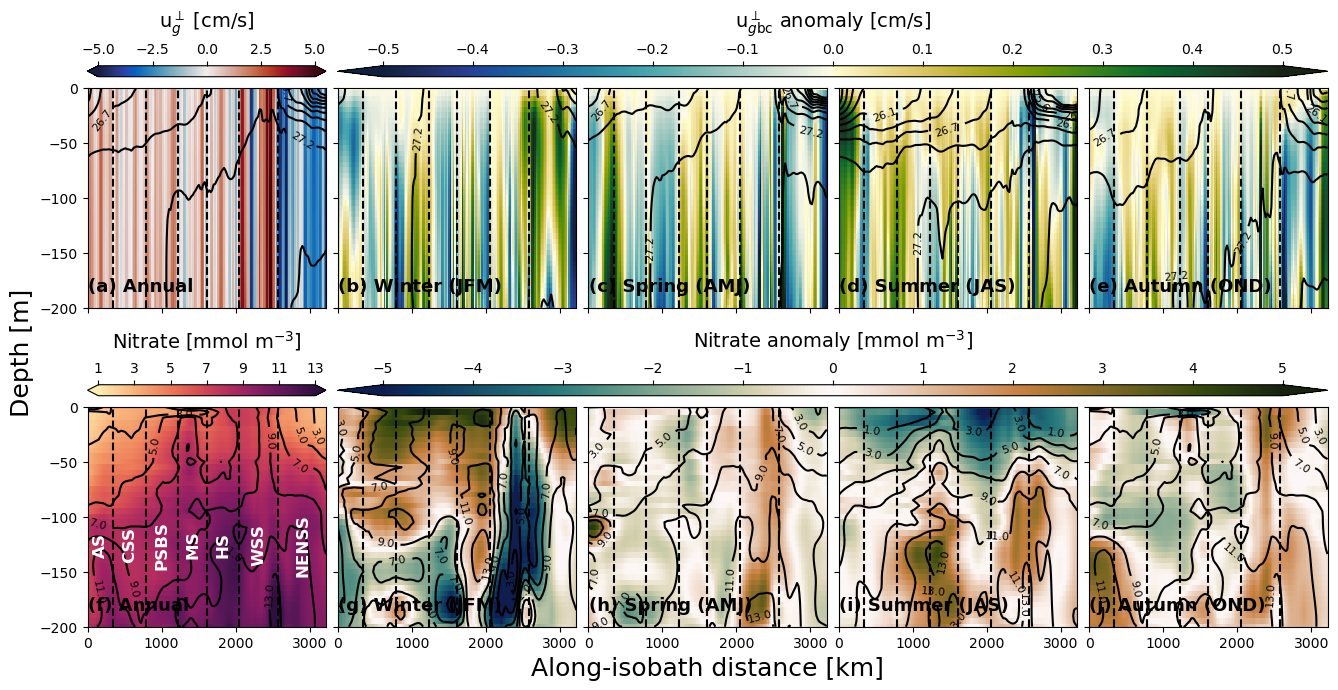

In [10]:
figsize = (16, 7)

css = []
nrows = 2
ncols = 5
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=figsize)

for j in range(nrows):
    axj = axs[j]
    for i in range(ncols):
        ti = ts[i]
        axi = axj[i]
        rhoi = rho.sel(t=ti)
        ugi, Ni = ug.sel(t=ti), N.sel(t=ti)

        if i>0: # ug seasonal anomaly.
            ugi_s = ugi - ugi.sel(z=0)
            ugi = ugi_s - ug_annual_s
            ugcmap = delta
            ugmaxi = ugmax_diff
            Ncmap = tarn_r
            Nmini, Nmaxi = -N_diff, N_diff
            Ni0 = Ni.copy()
            Ni = Ni - N_annual
        else:
            ugcmap = balance
            ugmaxi = ugmax
            Ncmap = matter
            Nmini, Nmaxi = Nmin, Nmax

        if j==0:
            csi = axi.pcolormesh(x, z, ugi, vmin=-ugmaxi, vmax=ugmaxi, cmap=ugcmap)
            cc = axi.contour(x, z, rhoi, levels=Dlevsc, colors="k")
            axi.clabel(cc, levels=Dccl, fmt="%1.1f", fontsize=8)
        elif j==1:
            csi = axi.pcolormesh(x, z, Ni, vmin=Nmini, vmax=Nmaxi, cmap=Ncmap)
            cc = axi.contour(x, z, Ni0, levels=Nlevs, colors="k")
            axi.clabel(cc, levels=Nlevs, fmt="%1.1f", fontsize=8)
        css.append(csi)

axs = axs.ravel()

axs[0].set_xlim(0, x[-1])
axs[0].set_ylim(-200, 0)
axs[0].set_ylabel(r"Depth [m]", y=-0.2, fontsize=18)
axs[-3].set_xlabel(r"Along-isobath distance [km]", fontsize=18)
for axi in axs:
    _ = [axi.axvline(x=dd, color="k", linestyle="--", linewidth=1.5, zorder=2) for dd in dibound[1:-1]]
annotate_segments2(axs[5], dibound=dibound, txt_segs=txt_segs, ytxt=-125, fontsize=12, txtcol="w", txtweight="bold")

l, r, w, h = 0, 1.05, 1, 0.05
w2 = 4.15

dugd = 0.1
dN_diff = 1
udiff_levs = np.concatenate([np.arange(-ugmax_diff, dugd, dugd), np.arange(dugd, ugmax_diff + dugd, dugd)])
Ndiff_levs = np.arange(-N_diff, N_diff + dN_diff, dN_diff)

ax1, ax2, ax3, ax4, ax5 = axs[:5]
ax6, ax7, ax8, ax9, ax10 = axs[5:]

cax = ax1.inset_axes([l, r, w, h])
cb = fig.colorbar(css[0], cax=cax, orientation="horizontal", extend="both")
cb.set_label(r"u$_g^\perp$ [cm/s]", fontsize=14, labelpad=10)
cb.ax.xaxis.set_ticks_position("top"); cb.ax.xaxis.set_label_position("top"); cb.ax.xaxis.set_ticks(uglevs)

cax = ax6.inset_axes([l, r, w, h])
cb = fig.colorbar(css[5], cax=cax, orientation="horizontal", extend="both")
cb.set_label(r"Nitrate [mmol m$^{-3}$]", fontsize=14, labelpad=10)
cb.ax.xaxis.set_ticks_position("top"); cb.ax.xaxis.set_label_position("top"); cb.ax.xaxis.set_ticks(Nlevs)

cax = ax2.inset_axes([l, r, w2, h])
cb = fig.colorbar(css[1], cax=cax, orientation="horizontal", extend="both")
cb.set_label(r"u$_{g\text{bc}}^\perp$ anomaly [cm/s]", fontsize=14, labelpad=10)
cb.ax.xaxis.set_ticks_position("top"); cb.ax.xaxis.set_label_position("top"); cb.ax.xaxis.set_ticks(udiff_levs)

cax = ax7.inset_axes([l, r, w2, h])
cb = fig.colorbar(css[6], cax=cax, orientation="horizontal", extend="both")
cb.set_label(r"Nitrate anomaly [mmol m$^{-3}$]", fontsize=14, labelpad=10)
cb.ax.xaxis.set_ticks_position("top"); cb.ax.xaxis.set_label_position("top"); cb.ax.xaxis.set_ticks(Ndiff_levs)

letters = list("abcdefghij")

xlett, ylett = 0.001, 0.1
for i, axi in enumerate(axs):
    txt = "(" + letters[i] + ")"
    if i==0 or i==5:
        txt += " Annual"
    elif i==1 or i==6:
        txt += " Winter (JFM)"
    elif i==2 or i==7:
        txt += " Spring (AMJ)"
    elif i==3 or i==8:
        txt += " Summer (JAS)"
    elif i==4 or i==9:
        txt += " Autumn (OND)"

    axi.text(xlett, ylett, txt, color="k", fontweight="black", ha="left", va="center", fontsize=13, transform=axi.transAxes, zorder=9999)

fig.subplots_adjust(hspace=0.45, wspace=0.05);

In [8]:
fig.savefig("fig4.png", bbox_inches="tight", dpi=200)

## Calculate segment-averaged depth-integrated nitrate transports and nitrate transport convergences.

In [16]:
Niz_segs_ti = dict()
ugNizint_segs_ti = dict()
Niz_segs = dict()
ugNizint_segs = dict()
ugiz_segs = dict()

nx = Ni.sizes["x"]
zflip = -Ni["z"].values
dz = np.gradient(zflip)[:, np.newaxis]
xx, zz = np.meshgrid(x, zflip)
ipts = (zz, xx)
for i in range(0, 5):
    ti = ts[i]
    print("===")
    print(ti)
    print("===")
    ugi, Ni = ug.sel(t=ti), N.sel(t=ti)

    # Calculate cross-isobath geostrophic nitrate flux ug*N.
    ugNi = ugN.sel(t=ti) # [mmol/m2/s]
    Niz = Ni.mean("z").values # Depth-averaged nitrate concetration [mmol/m3]
    ugNizint = (ugNi*dz).sum("z").values # Integrated ug*N [mmol/m/s], not segment-averaged yet.
    ugiz = (1e-2 * ugi).mean("z").values # Depth-averaged ug [m/s]

    # Segment-averaged depth-integrated ug*N and depth-avg N.
    Niz_segs_ti = dict()
    ugNizint_segs_ti = dict()
    ugiz_segs_ti = dict()
    for n in range(len(fseg) - 1):
        seg = txt_segs[n]
        fl, fr = fseg[n], fseg[n+1]
        dx = np.diff(di[fl:fr])*1e3
        Lx = dx.sum()

        Niz_aux = Niz[fl:fr]
        Niz_aux = 0.5*(Niz_aux[1:] + Niz_aux[:-1])
        Niz_segavg = np.nansum(Niz_aux*dx)/Lx # mmol/m3

        ugNizint_aux = ugNizint[fl:fr]
        ugNizint_aux = 0.5*(ugNizint_aux[1:] + ugNizint_aux[:-1])
        ugNizint_segavg = np.nansum(ugNizint_aux*dx)/Lx # mmol/m3
        ugNizint_segavg = np.nansum(ugNizint_aux*dx)/Lx # 1/s

        ugiz_aux = ugiz[fl:fr]
        ugiz_aux = 0.5*(ugiz_aux[1:] + ugiz_aux[:-1])
        ugiz_segavg = np.nansum(ugiz_aux*dx)/Lx # 1/s

        # print("Season: " + ti + " - Segment: " + seg + " -->    N = " + "%1.1f mmol/m3"%Niz_segavg)
        print("Season: " + ti + " - Segment: " + seg + " --> ug*N = " + "%1.1f mmol/m/s"%ugNizint_segavg)
        Niz_segs_ti.update({seg:Niz_segavg})
        ugNizint_segs_ti.update({seg:ugNizint_segavg})
        ugiz_segs_ti.update({seg:ugiz_segavg})

    Niz_segs.update({ti:Niz_segs_ti})
    ugNizint_segs.update({ti:ugNizint_segs_ti})
    ugiz_segs.update({ti:ugiz_segs_ti})

===
annual
===
Season: annual - Segment: AS --> ug*N = 14.4 mmol/m/s
Season: annual - Segment: CSS --> ug*N = 6.6 mmol/m/s
Season: annual - Segment: PSBS --> ug*N = 16.2 mmol/m/s
Season: annual - Segment: MS --> ug*N = 5.8 mmol/m/s
Season: annual - Segment: HS --> ug*N = 5.5 mmol/m/s
Season: annual - Segment: WSS --> ug*N = 27.4 mmol/m/s
Season: annual - Segment: NENSS --> ug*N = -37.5 mmol/m/s
===
JFM
===
Season: JFM - Segment: AS --> ug*N = 14.8 mmol/m/s
Season: JFM - Segment: CSS --> ug*N = 6.4 mmol/m/s
Season: JFM - Segment: PSBS --> ug*N = 15.7 mmol/m/s
Season: JFM - Segment: MS --> ug*N = 5.4 mmol/m/s
Season: JFM - Segment: HS --> ug*N = 7.3 mmol/m/s
Season: JFM - Segment: WSS --> ug*N = 18.4 mmol/m/s
Season: JFM - Segment: NENSS --> ug*N = -34.5 mmol/m/s
===
AMJ
===
Season: AMJ - Segment: AS --> ug*N = 15.9 mmol/m/s
Season: AMJ - Segment: CSS --> ug*N = 6.5 mmol/m/s
Season: AMJ - Segment: PSBS --> ug*N = 10.9 mmol/m/s
Season: AMJ - Segment: MS --> ug*N = 8.3 mmol/m/s
Season: AMJ

## Read in shelf nitrate concentrations from NSBC.

In [17]:
N_fileout = "../proc/Nmeans_shelf-NSBC.json"
Nmeans_shelf = read_json(N_fileout)
Nmeans_shelf_annual = Nmeans_shelf.mean()
Nmeans_shelf = Nmeans_shelf.to_dict()
Nmeans_shelf_annual["PSBS"] = np.nan # PSBC has a valid mean only for AMJ, NaN out the annual average.

FileNotFoundError: File ../Nmeans_shelf-NSBC.json does not exist